# 06 - Analyse de la vitesse et de la direction

La vitesse et la direction sont calcul?es ? partir de notre trajectoire estim?e, pas ? partir du groundtruth.


## 1. Importation des biblioth?ques


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append("../")
from src.analysis import compute_displacements, compute_distance, compute_speed, compute_direction, summarize_motion
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Chargement de `trajectory_estimated.csv`


In [2]:
results_path = Path("../results")
plots_path = results_path / "plots"
plots_path.mkdir(parents=True, exist_ok=True)
trajectory_path = results_path / "trajectory_estimated.csv"
trajectory_df = pd.read_csv(trajectory_path)
display(trajectory_df.head())
print("Nombre de positions :", len(trajectory_df))


,frame,x,y,tracked_points
0,0,636.849976,350.787506,80
1,1,636.511597,350.731049,80
2,2,635.575806,350.584442,80
3,3,634.690430,350.468353,80
4,4,633.782349,350.302094,80


Nombre de positions : 100


## 3. Calcul de dx et dy

`dx` et `dy` repr?sentent le d?placement horizontal et vertical entre deux frames.


In [3]:
analysis_df = compute_displacements(trajectory_df)
display(analysis_df[["frame", "x", "y", "dx", "dy"]].head())


,frame,x,y,dx,dy
0,0,636.849976,350.787506,0.000000,0.000000
1,1,636.511597,350.731049,-0.338379,-0.056458
2,2,635.575806,350.584442,-0.935791,-0.146606
3,3,634.690430,350.468353,-0.885376,-0.116089
4,4,633.782349,350.302094,-0.908081,-0.166260


## 4. Distance et vitesse

La distance est calcul?e avec `sqrt(dx? + dy?)`. La vitesse en pixels/frame est cette distance. La vitesse en pixels/seconde est obtenue en multipliant par le FPS.


In [4]:
fps = 30
analysis_df = compute_distance(analysis_df)
analysis_df = compute_speed(analysis_df, fps=fps)
display(analysis_df[["frame", "distance", "speed_px_per_frame", "speed_px_per_second"]].head())


,frame,distance,speed_px_per_frame,speed_px_per_second
0,0,0.000000,0.000000,0.000000
1,1,0.343056,0.343056,10.291694
2,2,0.947206,0.947206,28.416165
3,3,0.892954,0.892954,26.788627
4,4,0.923176,0.923176,27.695273


## 5. Direction

La direction est calcul?e avec `arctan2(dy, dx)` puis convertie en degr?s.


In [5]:
analysis_df = compute_direction(analysis_df)
display(analysis_df[["frame", "dx", "dy", "direction_deg"]].head())


,frame,dx,dy,direction_deg
0,0,0.000000,0.000000,0.000000
1,1,-0.338379,-0.056458,-170.527623
2,2,-0.935791,-0.146606,-171.096087
3,3,-0.885376,-0.116089,-172.530096
4,4,-0.908081,-0.166260,-169.624680


## 6. Visualisation de la vitesse et de la direction


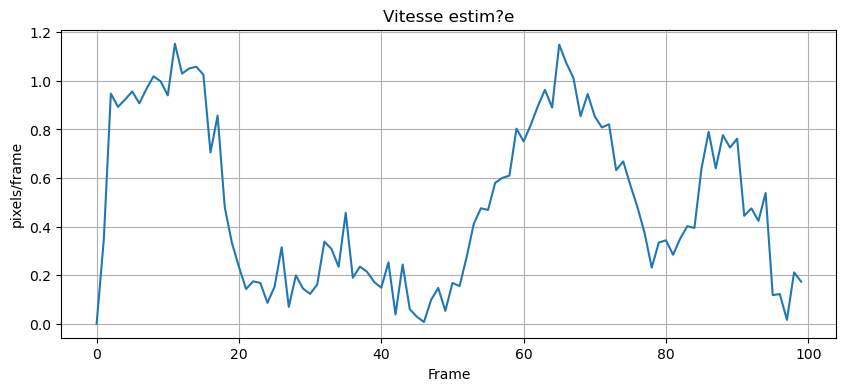

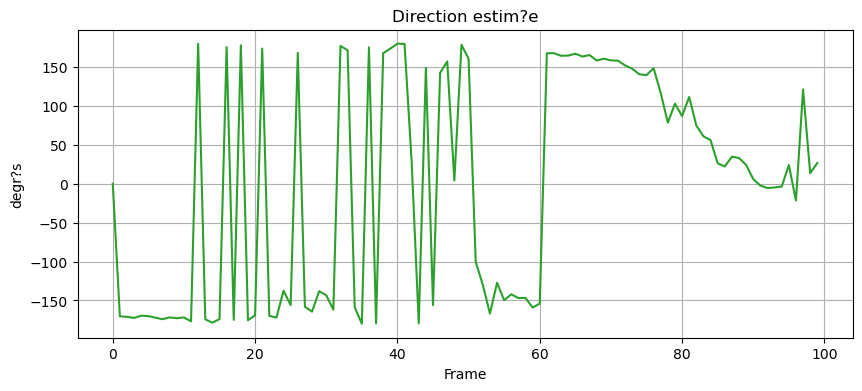

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(analysis_df["frame"], analysis_df["speed_px_per_frame"], color="tab:blue")
plt.title("Vitesse estim?e")
plt.xlabel("Frame")
plt.ylabel("pixels/frame")
plt.grid(True)
plt.savefig(plots_path / "speed_over_time_estimated.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(analysis_df["frame"], analysis_df["direction_deg"], color="tab:green")
plt.title("Direction estim?e")
plt.xlabel("Frame")
plt.ylabel("degr?s")
plt.grid(True)
plt.savefig(plots_path / "direction_over_time_estimated.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Sauvegarde des r?sultats


In [7]:
motion_analysis_path = results_path / "motion_analysis_estimated.csv"
analysis_df.to_csv(motion_analysis_path, index=False)
summary = summarize_motion(analysis_df)
print("R?sultats sauvegard?s dans :", motion_analysis_path)
print(summary)


R?sultats sauvegard?s dans : ..\results\motion_analysis_estimated.csv
{'number_of_frames': 100, 'total_distance': 50.08030712355129, 'mean_speed': 0.5008030712355129, 'max_speed': 1.1528236715230984, 'mean_direction': -1.9339992041675826, 'total_dx': -31.346435546875, 'total_dy': 4.40716552734375}


## 8. Conclusion

Nous avons calcul? la vitesse et la direction ? partir de notre trajectoire estim?e. Le groundtruth n?est pas utilis? dans cette analyse.
